> 📓 **Lesson 1.10 — Part 4 of 4: Chart Choice & the One Slide**
>
> This notebook was split out of the original single `data_visualization_lesson.ipynb` so each part can be opened and run on its own. If you are starting here rather than at Part 1, run the **Setup** cell below first — it loads the same data used throughout Lesson 1.10.
>
> Other notebooks in this set: `Part_1_three_pillars.ipynb`, `Part_2_matplotlib_fundamentals.ipynb`, `Part_3_seaborn.ipynb`

# Lesson 1.10: Data Visualisation & Storytelling

Lesson 1.8 asked *can I trust this data?* Lesson 1.9 asked *what is the pattern?* You answered both.
You have a table that shows exactly what is happening to the café chain.

This lesson is about the last twenty seconds — the part where the owner either acts on it or doesn't.

**Structure — the four learning outcomes, in order:**
* **Part 1: The Three Pillars** — *apply* perception, design and storytelling to fix a bad chart.
* **Part 2: Matplotlib Fundamentals** — *create* charts with the Figure → Axes → plot hierarchy.
* **Part 3: Seaborn for Statistical Graphics** — *use* the right statistical view for the data type.
* **Part 4: Chart Choice & the One Slide** — *select* the chart your message needs, and build it.

**How to work through this:** read the `# 👉` comment above each line before you run the cell. Charts are the one
topic where you learn most by breaking things on purpose, so several cells here are deliberately bad.


> **🧭 Today's flow — 180 minutes.** One message, four learning outcomes, in order:
>
> | | Section | Learning outcome | Time |
> |---|---|---|---|
> | — | Setup + why this matters | | 5 min |
> | **Part 1** | The Three Pillars | **Apply** perception, design, storytelling | 40 min |
> | ☕ | *Break* | | 10 min |
> | **Part 2** | Matplotlib Fundamentals | **Create** charts: Figure → Axes → plot | 45 min |
> | ☕ | *Break* | | 10 min |
> | **Part 3** | Seaborn | **Use** statistical graphics for the data type | 45 min |
> | **Part 4** | Chart Choice & the One Slide | **Select** the chart the message needs | 25 min |
>
> **The spine:** the same business problem as 1.9 — *The Daily Grind* café chain — and the same
> files. You already know the answer. Today you make it land.
>
> Each of Parts 1–3 ends with a **🛠️ Group Exercise**. Deep dives (colour theory, accessibility,
> Gestalt, the research behind pre-attentive processing) live in `reference.md`.


### The one rule this lesson is built on

> **The chart is chosen by the message, not by taste.**

Write the sentence you want the audience to leave with, in words, first. The chart type follows from
that sentence almost mechanically. Every mistake in Part 1 comes from doing it the other way round —
picking a chart, then hunting for something to say.


### Setup


In [1]:
# 👉 pandas for the data, matplotlib for drawing, seaborn for statistical charts.
#    `plt` and `sns` are the conventional nicknames -- you will see them in every tutorial.
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import FuncFormatter

# 👉 Housekeeping only: keep version-deprecation notices out of our output.
import warnings
warnings.filterwarnings("ignore")

# 👉 Draw charts underneath the cell that made them, inside the notebook.
%matplotlib inline


In [2]:
# 👉 The same café data as Lesson 1.9, plus the decision table you produced at the end of it.
sales = pd.read_csv("../data/daily_sales.csv", parse_dates=["date"])
outlets = pd.read_csv("../data/outlets.csv", parse_dates=["opened_date"])
tickets = pd.read_csv("../data/tickets_week.csv", parse_dates=["txn_datetime"])
decision = pd.read_csv("../data/lesson19_decision.csv", index_col="outlet_id")

decision.round(1)


,outlet_name,rev_2025_h1,change_pct,rent_pct_of_revenue,rev_per_staff_hour
outlet_id,,,,,
OUT-03,Marina Bay,203147.5,-27.9,28.4,19.9
OUT-01,Raffles Place,309339.2,-1.5,15.9,26.4
OUT-02,Tampines Mall,279272.0,1.3,14.6,25.5
OUT-04,Holland Village,253450.1,26.5,14.7,26.7
OUT-05,NaN,61309.5,NaN,NaN,26.0


In [3]:
# 👉 Two summaries we will chart all session. Both are straight out of Lesson 1.9.
#    (1) monthly revenue per outlet -- one column per outlet, dates on the index.
monthly = sales.pivot_table(
    index="date", columns="outlet_id", values="revenue_sgd", aggfunc="sum"
).resample("M").sum()

# 👉 (2) revenue by outlet and daypart.
by_daypart = sales.pivot_table(
    index="outlet_id", columns="daypart", values="revenue_sgd", aggfunc="sum"
)[["Morning", "Midday", "Evening"]]

# 👉 Friendly names, for chart labels. Codes belong in databases, not on slides.
names = outlets.set_index("outlet_id")["outlet_name"].to_dict()

monthly.tail(5).round(0)

# by_daypart.round(0)


outlet_id,OUT-01,OUT-02,OUT-03,OUT-04,OUT-05
date,,,,,
2025-02-28,47764.0,42186.0,32165.0,38456.0,0.0
2025-03-31,50549.0,48397.0,34927.0,45970.0,20493.0
2025-04-30,53250.0,47146.0,33777.0,41892.0,19595.0
2025-05-31,52570.0,50158.0,33822.0,44123.0,21221.0
2025-06-30,53255.0,44896.0,32818.0,44700.0,0.0


### 🎬 Why this matters — the same finding, three ways

**The situation.** You have five minutes at the end of a Monday meeting. The owner is deciding
whether to renew the Marina Bay lease. You already know the answer: chain revenue is flat because
Marina Bay is falling and Holland Village is rising, and Marina Bay's fall is a step dated to the
first week of November 2024.

Below is that finding presented three ways. Same data. Same truth. Run all three, then decide which
one makes somebody *do* something.


In [4]:
# 👉 Version 1: the numbers. Complete, precise, and almost impossible to read at speed.
monthly.round(0).tail(12)


outlet_id,OUT-01,OUT-02,OUT-03,OUT-04,OUT-05
date,,,,,
2024-07-31,55315.0,48409.0,48581.0,36779.0,0.0
2024-08-31,52530.0,48299.0,47079.0,38089.0,0.0
2024-09-30,50083.0,45214.0,43679.0,36634.0,0.0
2024-10-31,54212.0,44320.0,46138.0,37368.0,0.0
2024-11-30,48362.0,45761.0,35344.0,37488.0,0.0
2024-12-31,51839.0,46734.0,33956.0,39548.0,0.0
2025-01-31,51951.0,46489.0,35638.0,38309.0,0.0
2025-02-28,47764.0,42186.0,32165.0,38456.0,0.0
2025-03-31,50549.0,48397.0,34927.0,45970.0,20493.0


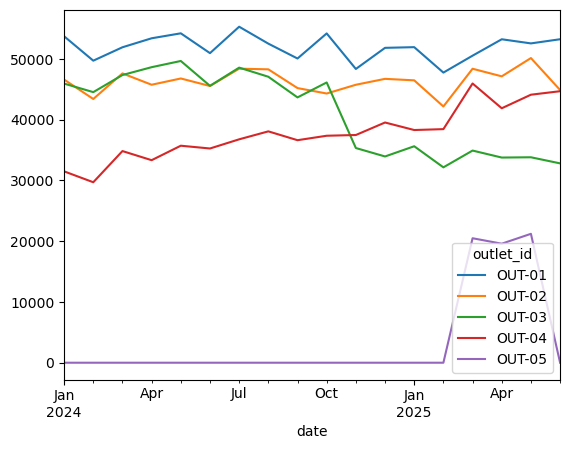

In [5]:
# 👉 Version 2: a chart, made without thinking. Every default left as it came.
monthly.plot()
plt.show()


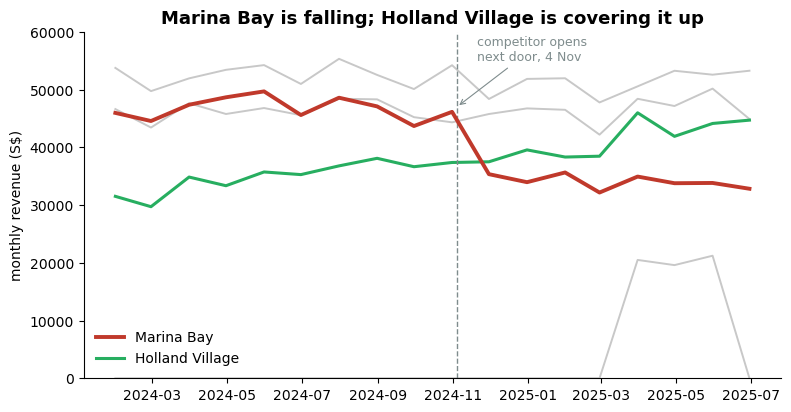

In [6]:
# 👉 Version 3: the same numbers, drawn to make one point. Read the code later --
#    for now just compare what your eye does with this versus the two above.
# color codes: https://htmlcolorcodes.com/color-names/

fig, ax = plt.subplots(figsize=(9, 4.5))

for col in monthly.columns:
    if col == "OUT-03":
        ax.plot(monthly.index, monthly[col], color="#c0392b", linewidth=2.8, label="Marina Bay", zorder=3) # zorder controls which lines are drawn on top of which others, 3 is the highest here
    elif col == "OUT-04":
        ax.plot(monthly.index, monthly[col], color="#27ae60", linewidth=2.2, label="Holland Village", zorder=2)
    else:
        ax.plot(monthly.index, monthly[col], color="#c8c8c8", linewidth=1.4, zorder=1)

ax.axvline(pd.Timestamp("2024-11-04"), color="#7f8c8d", linestyle="--", linewidth=1)
ax.annotate("competitor opens\nnext door, 4 Nov",
            xy=(pd.Timestamp("2024-11-04"), 47000), xytext=(pd.Timestamp("2024-11-20"), 55000),
            fontsize=9, color="#7f8c8d",
            arrowprops=dict(arrowstyle="->", color="#7f8c8d", linewidth=0.8))

ax.set_title("Marina Bay is falling; Holland Village is covering it up", fontsize=13, weight="bold")
ax.set_ylabel("monthly revenue (S$)")
ax.set_ylim(0, 60000)
ax.legend(frameon=False, loc="lower left") # remove the box around the legend
ax.spines[["top", "right"]].set_visible(False) # remove the top and right borders
plt.show()


**What changed between versions 2 and 3?** Nothing about the data. Four things about the drawing:

1. **One sentence as the title.** Not "Monthly Revenue" — the actual finding, in words.
2. **Colour used as an argument.** Two lines carry the point; the other three went grey. Your eye
   found the red line before you consciously read anything. That reflex is *pre-attentive processing*,
   and it fires in 200 to 500 milliseconds. Charts either use it or waste it.
3. **The cause annotated on the chart.** The reader does not have to be told separately.
4. **Clutter removed.** Two spines gone, no box round the legend, no chart junk competing for attention.

That is the whole lesson: **perception** (how eyes work), **design** (honest, uncluttered choices),
**storytelling** (one message, stated). Everything else is syntax.


---

## Part 4: Chart Choice & the One Slide

**Learning outcome 4:** *Select the right visualisation type for a given analytical context and
audience.*

**Goal:** the owner gets twenty seconds. Build the one figure that carries the decision.

⏱️ ~25 min


### 4.1: The message picks the chart (Self-Study)

Start from the sentence, not the chart type. This table is the whole of chart selection:

| The sentence you want them to leave with | Chart | Why it works |
|---|---|---|
| "X changed over time" | **line** | position over a continuous axis; the eye reads slope as change |
| "X is bigger than Y" | **bar** (from zero) | length on a shared baseline is the most accurately judged channel |
| "X is made up of these parts" | **stacked bar** or **treemap** | one whole, divided; pie only for 2–3 slices |
| "X and Y move together" | **scatter** | two positions at once reveals the joint pattern |
| "X varies more than you think" | **box**, **violin**, **histogram** | shows the spread an average conceals |
| "the pattern differs by group" | **small multiples** | shared axes make shapes comparable |
| "this cell is the hot spot" | **heatmap** | colour across two categorical axes |
| "one number matters" | **big number** with a line for context | do not chart a single figure; write it |

**And the audience decides the depth, not the truth:**

| Audience | Wants | So the chart is |
|---|---|---|
| Owner / executive | the decision | one panel, finding as the title, annotated cause |
| Manager | what to change | the driver broken out, comparison to target |
| Data team | the method | small multiples, distributions, uncertainty shown |

Same analysis every time. Only the framing changes. Presenting an executive the chart you built for
the data team is the single most common failure in this lesson — and it reads as "you did not think
about me".


### 4.2: The owner's slide

The message: **"The chain looks flat because Marina Bay's collapse is being hidden by Holland
Village's growth — and Marina Bay now pays double the rent share for the least productive hour."**

Two panels: the trend that carries the finding, and the cost that makes it a decision.


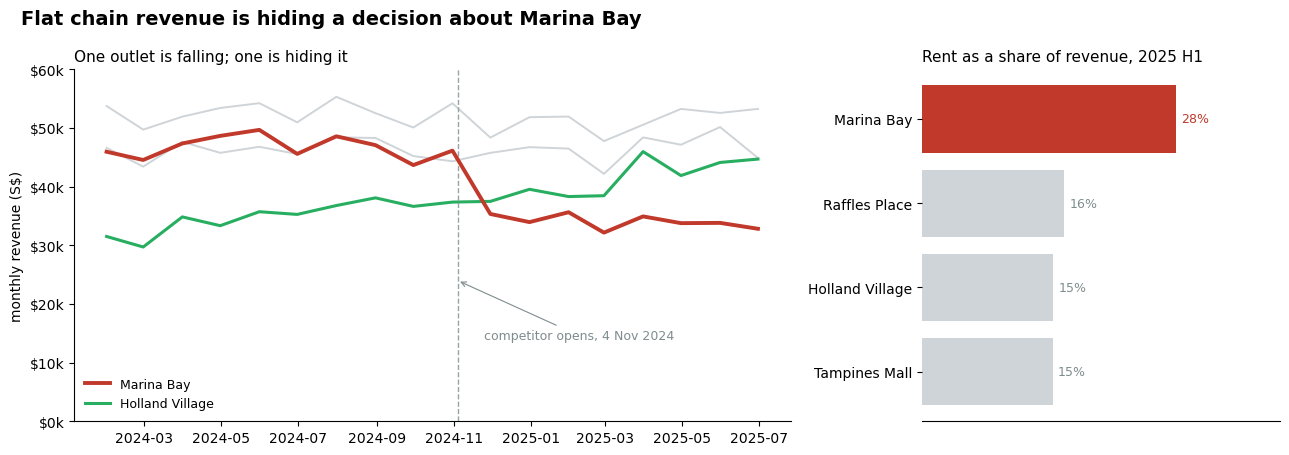

In [7]:
# 👉 One Figure, two Axes, sized so the trend gets more room than the bars.
#    `gridspec_kw` sets the relative widths.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(13, 4.6), gridspec_kw={"width_ratios": [2, 1]})

# ---- left panel: the trend -------------------------------------------------
for col in ["OUT-01", "OUT-02", "OUT-03", "OUT-04"]:
    if col == "OUT-03":
        style = dict(color="#c0392b", linewidth=2.8, zorder=3, label="Marina Bay")
    elif col == "OUT-04":
        style = dict(color="#27ae60", linewidth=2.2, zorder=2, label="Holland Village")
    else:
        style = dict(color="#cfd4d8", linewidth=1.4, zorder=1)
    ax1.plot(monthly.index, monthly[col], **style)

ax1.axvline(pd.Timestamp("2024-11-04"), color="#95a5a6", linestyle="--", linewidth=1)
ax1.annotate("competitor opens, 4 Nov 2024",
             xy=(pd.Timestamp("2024-11-04"), 24000),
             xytext=(pd.Timestamp("2024-11-25"), 14000),
             fontsize=9, color="#7f8c8d",
             arrowprops=dict(arrowstyle="->", color="#7f8c8d", linewidth=0.8))

ax1.set_ylim(0, 60000)
ax1.set_ylabel("monthly revenue (S$)")
ax1.set_title("One outlet is falling; one is hiding it", loc="left", fontsize=11)
ax1.legend(frameon=False, loc="lower left", fontsize=9)
ax1.spines[["top", "right"]].set_visible(False)
ax1.yaxis.set_major_formatter(FuncFormatter(lambda v, _: f"${v/1000:,.0f}k"))

# ---- right panel: the cost ------------------------------------------------
rent = decision["rent_pct_of_revenue"].dropna().sort_values()
bar_colours = ["#c0392b" if i == "OUT-03" else "#cfd4d8" for i in rent.index]

ax2.barh([names[i] for i in rent.index], rent.values, color=bar_colours)
for y, v in enumerate(rent.values):
    ax2.text(v + 0.6, y, f"{v:.0f}%", va="center", fontsize=9,
             color="#c0392b" if rent.index[y] == "OUT-03" else "#7f8c8d")

ax2.set_xlim(0, 40)
ax2.set_title("Rent as a share of revenue, 2025 H1", loc="left", fontsize=11)
ax2.spines[["top", "right", "left"]].set_visible(False)
ax2.set_xticks([])
ax2.grid(False)

# ---- the message, as the Figure title ------------------------------------
fig.suptitle("Flat chain revenue is hiding a decision about Marina Bay",
             fontsize=14, weight="bold", x=0.02, ha="left")

plt.tight_layout()
fig.savefig("../visualisations/owner_slide.png", dpi=150, bbox_inches="tight")
plt.show()


### 4.3: The twenty seconds of script that goes with it

A chart does not present itself. Three acts, one sentence each:

> **Act 1 — context.** "Chain revenue has been flat for two quarters, so nothing looks urgent."
>
> **Act 2 — the finding.** "It is flat because these two cancel out: Marina Bay is down 28% year on
> year, Holland Village is up 27%. Marina Bay's fall happened in one week last November, when a
> competitor opened next door — and it has been flat at the new level ever since."
>
> **Act 3 — the decision.** "Marina Bay now spends 28% of its revenue on rent against 15% everywhere
> else, and earns \$20 per staff hour against \$25--27. Before you sign the lease, the question is whether
> that November step can be reversed. If not, the rent is the wrong price for this outlet now."

**Notice what the script does not do.** It does not say "close Marina Bay". Your job was to make the
comparison unavoidable; the decision is hers. That distinction is what separates an analyst from
someone with an agenda and a chart.


## 👉 One last check on your own work. Run this over any chart before you send it.

    ☑️ Does the title state the finding, not the metric?
    ☑️ Do bar charts start at zero?
    ☑️ Is colour carrying meaning, not decoration?
    ☑️ Are there fewer than about five things demanding attention?
    ☑️ Do axis labels include units?
    ☑️ Would this be readable printed in black and white?
    ☑️ If the reader saw only this chart, with no voiceover, would they get the message?

## 🎯 Wrap-Up

1. **The chart is chosen by the message.** Write the sentence first; the chart type follows.
2. **Perception is a budget.** Colour is your loudest tool — spend it on one thing, and grey the rest.
3. **Bars start at zero.** Lines do not have to. Length is compared; position is read for change.
4. **The title is the finding.** "Monthly Revenue" tells no one anything. Use the sentence.
5. **Annotate the cause on the chart.** A chart that travels without you must explain itself.
6. **Distributions before averages.** An $8.38 mean ticket described a customer who does not exist.
7. **An absence is a finding.** Identical box plots ruled out "customers spend less" in one chart.
8. **Small multiples need `sharey=True`,** or they mislead by accident.
9. **Your job is to make the comparison unavoidable** — not to make the decision.

**Next Steps:**
- Complete the [Assignment](./assignment.md) — critique, redesign, and build your own one slide.
- Module 1 is complete: you can now take a messy file (1.8), find the pattern in it (1.9), and make
  someone act on it (1.10). That is the whole job.


### 📦 Appendix — self-study

In `reference.md`, with worked examples:

- **Colour theory and accessibility:** qualitative vs sequential vs diverging palettes; colour-blind-safe
  choices; why `viridis` exists.
- **Gestalt principles** and the research behind pre-attentive processing.
- **`pairplot`, `jointplot`, `FacetGrid`** — the rest of seaborn's figure-level API.
- **Styles and rcParams:** `sns.set_theme`, `plt.rcParams`, house-style defaults.
- **Saving for print vs screen:** dpi, vector versus raster, `bbox_inches`.
- **Interactive charts:** where plotly and altair fit, and when they are worth the dependency.


---

## 🏁 Lesson 1.10 Complete — Module 1's data-to-decision arc is done!

You've covered all four sections:
- **Part 1:** The Three Pillars — perception, design, storytelling
- **Part 2:** Matplotlib Fundamentals — Figure, Axes, plot
- **Part 3:** Seaborn for Statistical Graphics — distributions, categorical views, relationships
- **Part 4:** Chart Choice & the One Slide — picking the chart and building the owner's slide

**Next step:** work through `assignment.md` to practise the full pipeline end to end.